# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [38]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [3]:
DATA_DIR = "data"

tracks = pd.read_parquet(f"{DATA_DIR}/tracks.parquet")
catalog_names = pd.read_parquet(f"{DATA_DIR}/catalog_names.parquet")
interactions = pd.read_parquet(f"{DATA_DIR}/interactions.parquet")

In [4]:
print(f"tracks: {tracks.shape}")
print(f"catalog_names: {catalog_names.shape}")
print(f"interactions: {interactions.shape}")

tracks: (1000000, 4)
catalog_names: (1812471, 3)
interactions: (222629898, 4)


# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [5]:
# просмотр структуры данных

print("tracks")
display(tracks.head())
tracks.info()

print("\ncatalog_names")
display(catalog_names.head())
catalog_names.info()

print("\ninteractions")
display(interactions.head())
interactions.info()

tracks


,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   albums    1000000 non-null  object
 2   artists   1000000 non-null  object
 3   genres    1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB

catalog_names


,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow
3,17,album,Graffiti Soul
4,26,album,Blues Six Pack


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   type    object
 2   name    object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB

interactions


,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22


<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB


In [25]:
# проверка пропусков

print("tracks")
display(tracks.isna().sum())

print("catalog_names")
display(catalog_names.isna().sum())

print("interactions")
display(interactions.isna().sum())


tracks


track_id    0
albums      0
artists     0
genres      0
dtype: int64

catalog_names


id      0
type    0
name    0
dtype: int64

interactions


user_id       0
track_id      0
track_seq     0
started_at    0
dtype: int64

In [26]:
# Проверяем существующие типы
catalog_names["type"].value_counts()

type
track     1000000
album      658724
artist     153581
genre         166
Name: count, dtype: int64

In [27]:
# идентификаторы объектов из каталога

album_ids = set(
    catalog_names.loc[
        catalog_names["type"] == "album",
        "id"
    ]
)

artist_ids = set(
    catalog_names.loc[
        catalog_names["type"] == "artist",
        "id"
    ]
)

genre_ids = set(
    catalog_names.loc[
        catalog_names["type"] == "genre",
        "id"
    ]
)

In [28]:
# проверка треков на неизвестные альбомы, исполнителей и жанры

unknown_albums = tracks["albums"].map(
    lambda ids: any(item_id not in album_ids for item_id in ids)
)

unknown_artists = tracks["artists"].map(
    lambda ids: any(item_id not in artist_ids for item_id in ids)
)

unknown_genres = tracks["genres"].map(
    lambda ids: any(item_id not in genre_ids for item_id in ids)
)

print(
    "Треков с неизвестными альбомами:",
    unknown_albums.sum()
)

print(
    "Треков с неизвестными исполнителями:",
    unknown_artists.sum()
)

print(
    "Треков с неизвестными жанрами:",
    unknown_genres.sum()
)

Треков с неизвестными альбомами: 0
Треков с неизвестными исполнителями: 0
Треков с неизвестными жанрами: 48345


In [23]:
# поиск неизвестных идентификаторов жанров

unknown_genre_ids = {
    genre_id
    for genres in tracks["genres"]
    for genre_id in genres
    if genre_id not in genre_ids
}

print(f"Количество неизвестных жанров: {len(unknown_genre_ids)}")
print(f"Неизвестные genre_id: {sorted(unknown_genre_ids)}")

Количество неизвестных жанров: 30
Неизвестные genre_id: [124, 126, 130, 131, 132, 133, 134, 135, 146, 148, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169]


In [31]:
# проверим что останутся ли жанры в треках при удалении неизвестных жанров

tracks_with_only_unknown_genres = tracks["genres"].map(
    lambda genres: all(
        genre_id not in genre_ids
        for genre_id in genres
    )
)

print(
    "Треков только с неизвестными жанрами:",
    tracks_with_only_unknown_genres.sum()
)

Треков только с неизвестными жанрами: 3694


In [32]:
# удаление неизвестных жанров из списков genres

tracks["genres"] = tracks["genres"].map(
    lambda genres: [
        genre_id
        for genre_id in genres
        if genre_id in genre_ids
    ]
)

In [34]:
# повторная проверка неизвестных жанров

unknown_genres = tracks["genres"].map(
    lambda ids: any(
        genre_id not in genre_ids
        for genre_id in ids
    )
)

print(
    "Треков с неизвестными жанрами:",
    unknown_genres.sum()
)

print(
    "Треков без жанров:",
    tracks["genres"].map(len).eq(0).sum()
)

Треков с неизвестными жанрами: 0
Треков без жанров: 3694


# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

В ходе первичного анализа данных явных проблем с типами данных и пропусками не обнаружено.

Проверка ссылок на объекты каталога показала, что все идентификаторы альбомов и исполнителей корректны. При этом были обнаружены 30 идентификаторов жанров, отсутствующих в каталоге. Такие идентификаторы встречались у 48 345 треков.

В качестве корректирующего действия неизвестные идентификаторы жанров были удалены из списков `genres`. После обработки у 3 694 треков список жанров остался пустым.

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

In [36]:
tracks_per_user = (
    interactions.groupby("user_id")["track_id"]
    .nunique()
)

tracks_per_user.describe()

count    1.373221e+06
mean     1.621224e+02
std      3.512846e+02
min      1.000000e+00
25%      2.300000e+01
50%      5.500000e+01
75%      1.540000e+02
max      1.663700e+04
Name: track_id, dtype: float64

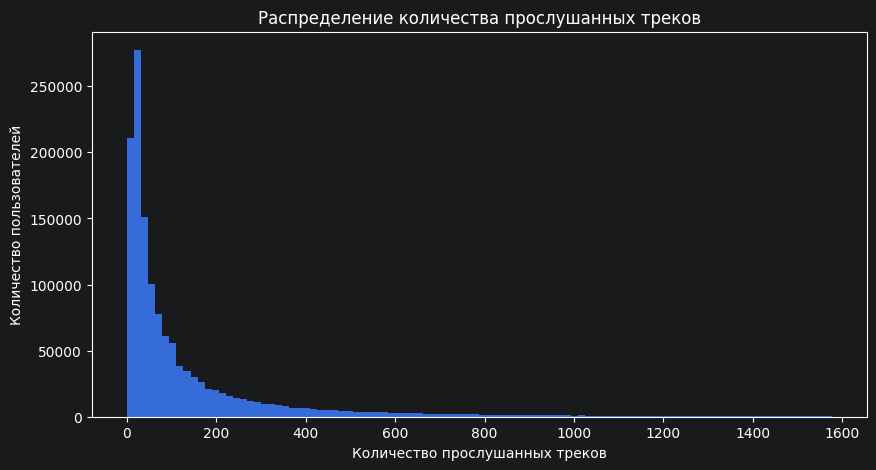

In [39]:
# распределение количества прослушанных треков

upper_bound = tracks_per_user.quantile(0.99)

plt.figure(figsize=(10, 5))

plt.hist(
    tracks_per_user[tracks_per_user <= upper_bound],
    bins=100
)

plt.title("Распределение количества прослушанных треков")
plt.xlabel("Количество прослушанных треков")
plt.ylabel("Количество пользователей")
plt.show()

Наиболее популярные треки

In [41]:
# наиболее популярные треки

track_names = catalog_names[
    catalog_names["type"] == "track"
][["id", "name"]]

popular_tracks = (
    interactions.groupby("track_id")
    .size()
    .reset_index(name="listen_count")
    .sort_values("listen_count", ascending=False)
    .head(20)
    .merge(
        track_names,
        left_on="track_id",
        right_on="id",
        how="left"
    )
    [["track_id", "name", "listen_count"]]
)

popular_tracks

,track_id,name,listen_count
0,53404,Smells Like Teen Spirit,111062
1,33311009,Believer,106921
2,178529,Numb,101924
3,35505245,I Got Love,99490
4,65851540,Юность,86670
5,24692821,Way Down We Go,86246
6,32947997,Shape of You,85886
7,51241318,In The End,85244
8,795836,Shape Of My Heart,85042
9,45499814,Life,84748


Наиболее популярные жанры

In [43]:
# количество прослушиваний каждого трека

track_listens = (
    interactions.groupby("track_id")
    .size()
    .reset_index(name="listen_count")
)

# Присоединяем жанры
tracks_with_listens = tracks[
    ["track_id", "genres"]
].merge(
    track_listens,
    on="track_id",
    how="left"
)

tracks_with_listens["listen_count"] = (
    tracks_with_listens["listen_count"]
    .fillna(0)
    .astype("int64")
)

# Подсчёт суммы прослушиваний
popular_genres = (
    tracks_with_listens
    .explode("genres")
    .groupby("genres")["listen_count"]
    .sum()
    .reset_index()
    .sort_values("listen_count", ascending=False)
    .head(20)
)

# Подтягиваем имена жанров
genre_names = catalog_names[
    catalog_names["type"] == "genre"
][["id", "name"]]

popular_genres = (
    popular_genres
    .merge(
        genre_names,
        left_on="genres",
        right_on="id",
        how="left"
    )
    [["genres", "name", "listen_count"]]
)

popular_genres

,genres,name,listen_count
0,11,pop,55578312
1,75,rap,37799821
2,102,allrock,31092013
3,20,ruspop,26626241
4,3,rusrap,25303695
5,68,electronics,20120981
6,16,dance,16291557
7,2,rusrock,13166147
8,14,rock,12772644
9,47,metal,12437375


Треки, которые никто не прослушал

In [44]:
# треки, которые никто не прослушал

listened_track_ids = set(
    interactions["track_id"].unique()
)

unlistened_tracks = tracks[
    ~tracks["track_id"].isin(listened_track_ids)
]

print(
    "Количество треков без прослушиваний:",
    len(unlistened_tracks)
)

unlistened_tracks.head()

Количество треков без прослушиваний: 0


,track_id,albums,artists,genres


# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

# Топ популярных

Рассчитаем рекомендации как топ популярных.

# Персональные

Рассчитаем персональные рекомендации.

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.